Blazar selezionato: J0133.2-5159
Numero linee osservate usate: 2


100%|██████████| 4000/4000 [07:55<00:00,  8.42it/s]


Blazar: J0133
Modello: SS + ADAF unificato
Switch: log10(mdot) = -2.0
Numero walkers = 32
Numero steps   = 4000
Burn-in        = 1200
Thin           = 15

log10(m)    = 6.865 [6.327, 10.972]
log10(mdot) = -0.653 [-2.240, -0.120]
m_median    = 7.322e+06 Msun
mdot_median = 2.224e-01
Regime mediano = SS

Frazione posterior ADAF = 0.469
Frazione posterior SS   = 0.531
Acceptance fraction media = 0.354
Autocorrelation time: [61.48459415 69.54212544]
Nsteps / tau: [65.05694728 57.51909328]


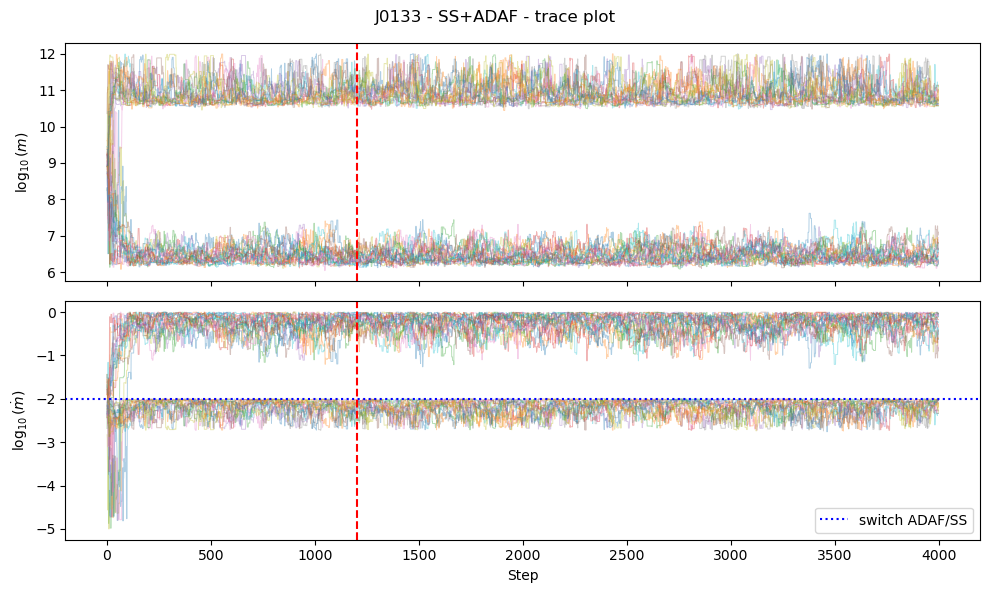

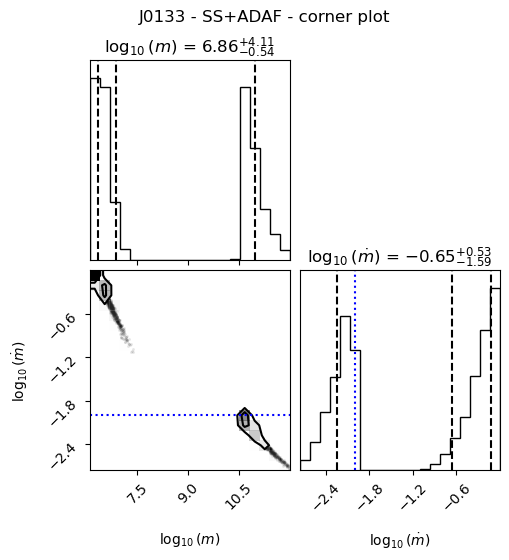

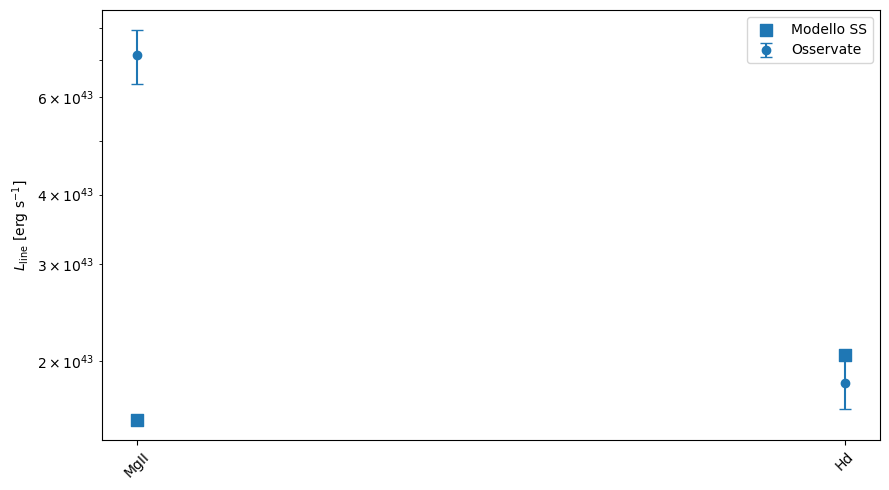

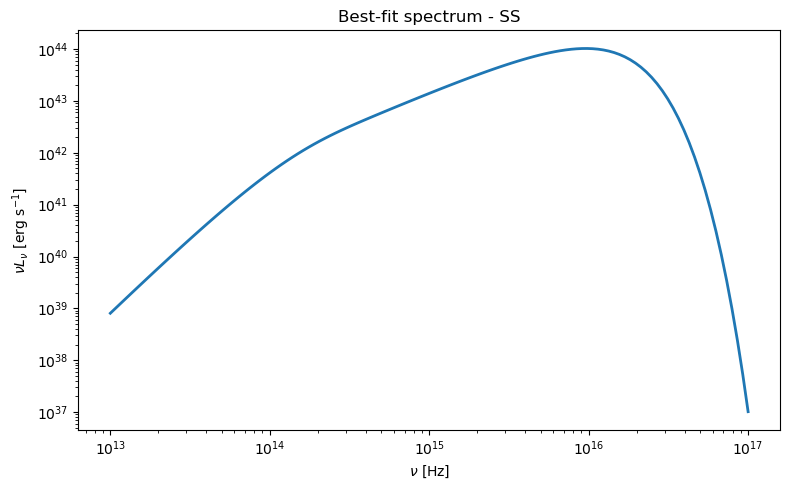

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import root
from scipy.special import kv
import emcee
import corner

# ==========================================================
# COSTANTI FISICHE
# ==========================================================
c = 2.99792458e10
G = 6.67430e-8
h = 6.62607015e-27
kB = 1.380649e-16
sigma_sb = 5.670374419e-5
Msun = 1.98847e33


# ==========================================================
# FUNZIONI UTILI
# ==========================================================
def trova_colonna(df, possibili_nomi, obbligatoria=True):
    for nome in possibili_nomi:
        if nome in df.columns:
            return nome
    if obbligatoria:
        raise ValueError(f"Non trovo nessuna di queste colonne: {possibili_nomi}")
    return None


def leggi_transizioni(file_transizioni):
    names, Eion, nu_ion_list = np.genfromtxt(
        file_transizioni,
        dtype=("U50", float, float),
        unpack=True
    )

    return pd.DataFrame({
        "line_name": names,
        "E_ion": Eion,
        "nu_ion": nu_ion_list
    })


def estrai_linee_osservate(row, norm_columns, rel_err):
    risultati = []

    for col in norm_columns:
        valore = row[col]

        if pd.isna(valore) or valore <= 0:
            continue

        line_name = col.replace("_norm", "")
        unc_col = f"{line_name}_norm_unc"

        L_line = valore * 1e42

        if unc_col in row.index and pd.notna(row[unc_col]) and row[unc_col] > 0:
            sigma_L = row[unc_col] * 1e42
        else:
            sigma_L = rel_err * L_line

        risultati.append({
            "line_name": line_name,
            "norm_value": valore,
            "L_line_obs": L_line,
            "sigma_L": sigma_L
        })

    return pd.DataFrame(risultati)


def prepara_dati_blazar(label_target, file_linee, file_transizioni, rel_err):
    df_tab = pd.read_csv(file_linee)
    df_trans = leggi_transizioni(file_transizioni)

    col_name_tab = trova_colonna(
        df_tab,
        ["label", "file_name", "name", "nome", "blazar"]
    )

    norm_columns = [col for col in df_tab.columns if col.endswith("_norm")]

    df_all = df_tab.rename(columns={col_name_tab: "label"}).copy()
    df_all["label"] = df_all["label"].astype(str).str.strip()

    label_target_clean = str(label_target).strip()

    df_match = df_all[df_all["label"] == label_target_clean].copy()

    if df_match.empty:
        df_match = df_all[
            df_all["label"].str.contains(label_target_clean, case=False, na=False)
        ].copy()

    if df_match.empty:
        print("Label disponibili:")
        print(df_all["label"].drop_duplicates().sort_values().tolist())
        raise ValueError(f"Nessun blazar trovato per label_target = '{label_target}'")

    if len(df_match) > 1:
        print("Trovati più blazar compatibili:")
        print(df_match["label"].tolist())
        print("Uso il primo della lista.")

    row = df_match.iloc[0]

    df_obs = estrai_linee_osservate(row, norm_columns, rel_err)

    df_obs = df_obs.merge(
        df_trans[["line_name", "E_ion", "nu_ion"]],
        on="line_name",
        how="left"
    )

    df_obs["sigma_L"] = pd.to_numeric(df_obs["sigma_L"], errors="coerce")

    df_obs.loc[
        df_obs["sigma_L"].isna() | (df_obs["sigma_L"] <= 0),
        "sigma_L"
    ] = rel_err * df_obs["L_line_obs"]

    print(f"Blazar selezionato: {row['label']}")
    print(f"Numero linee osservate usate: {len(df_obs)}")

    return df_all, df_trans, df_obs


# ==========================================================
# MODELLO SS
# ==========================================================
def costruisci_spettro_ss(MBH_solar, mdot_edd, cfg):
    MBH = MBH_solar * Msun

    eta = cfg["eta"]
    Nr = cfg["Nr"]
    Nnu_ss = cfg["Nnu_ss"]
    nu_min = cfg["nu_min_ss"]
    nu_max = cfg["nu_max_ss"]

    Ledd = 1.3e38 * MBH_solar
    Ldisk = mdot_edd * Ledd
    Mdot = Ldisk / (eta * c**2)

    Rs = 2 * G * MBH / c**2
    Rin = 3 * Rs
    Rout = 3000 * Rs
    R = np.logspace(np.log10(Rin), np.log10(Rout), Nr)

    f = 1.0 - np.sqrt(Rin / R)
    f = np.clip(f, 0.0, None)

    T = ((3 * G * MBH * Mdot) / (8 * np.pi * sigma_sb * R**3) * f) ** 0.25

    nu = np.logspace(np.log10(nu_min), np.log10(nu_max), Nnu_ss)

    Bnu = np.zeros((Nnu_ss, Nr))

    for j in range(Nr):
        if T[j] <= 0:
            continue

        x = h * nu / (kB * T[j])
        x = np.clip(x, 1e-12, 700.0)

        Bnu[:, j] = (2 * h * nu**3 / c**2) / (np.exp(x) - 1.0)

    integrand = R[None, :] * Bnu
    I_nu = np.trapezoid(integrand, R, axis=1)

    Lnu = 4 * np.pi**2 * I_nu
    nuLnu = nu * Lnu

    info = {
        "regime": "SS",
        "MBH_solar": MBH_solar,
        "mdot_edd": mdot_edd,
        "Ledd": Ledd,
        "Ldisk": Ldisk,
        "Mdot_cgs": Mdot
    }

    return nu, Lnu, nuLnu, info


# ==========================================================
# MODELLO ADAF
# ==========================================================
def bessk(n, x):
    return kv(n, x)


def g_adaf(teta):
    val = bessk(2, 1.0 / teta)

    if not np.isfinite(val) or val <= 0:
        return np.nan

    return (
        (1.0 / val)
        * (2.0 + 2.0 * teta + 1.0 / teta)
        * np.exp(-1.0 / teta)
    )


def temperat(y, mdot, m, beta, cfg):
    if not np.all(np.isfinite(y)):
        return [1e99, 1e99, 1e99]

    if mdot <= 0 or m <= 0 or beta <= 0 or beta >= 1:
        return [1e99, 1e99, 1e99]

    if np.any(np.abs(y) > 1e3):
        return [1e99, 1e99, 1e99]

    alfa = cfg["alfa"]
    rmin = cfg["rmin"]
    rmax = cfg["rmax"]
    delta = cfg["delta"]
    c1 = cfg["c1"]
    c3 = cfg["c3"]
    tnorm = cfg["tnorm"]

    ff = y[2]**2
    xm = 1e3 * y[1]**2
    teta = y[0]**2

    if ff <= 0 or xm <= 0 or teta <= 1e-12:
        return [1e99, 1e99, 1e99]

    gval = g_adaf(teta)

    if not np.isfinite(gval):
        return [1e99, 1e99, 1e99]

    s1 = 1.42e9 * alfa**(-0.5) * np.sqrt(1 - beta) * c1**(-0.5) * c3**0.5
    s2 = 1.19e-13 * xm

    q1 = 1.2e4 * gval * alfa**(-2) * c1**(-2) * c3 * beta * m * mdot**2 / rmin
    q2 = delta * 9.39e4 * ((1 - beta) / ff) * c3 * m * mdot / rmin
    q = q1 + q2

    nup = s1 * s2 * m**(-0.5) * mdot**0.5 * (teta / tnorm)**2 * rmin**(-5/4)

    if not np.isfinite(nup) or nup <= 0:
        return [1e99, 1e99, 1e99]

    psinc = (
        53.0 * (xm / 1000.0)**3 *
        (teta / (1e9 * tnorm))**7 *
        m**0.5 * mdot**1.5
    )

    abig = 1 + 4*teta + 16*teta**2
    tau = 23.87 * mdot

    if tau <= 0 or abig <= 1:
        return [1e99, 1e99, 1e99]

    alfac = -np.log(tau) / np.log(abig)

    try:
        base_graffa = (6.2e7 * (teta / (1e9 * tnorm))) / (nup * 1e-12)
        if base_graffa <= 0 or not np.isfinite(base_graffa):
            return [1e99, 1e99, 1e99]

        graffa = base_graffa**(1 - alfac) - 1
        pcomp = (psinc / 0.71) / (1 - alfac) * graffa
    except Exception:
        return [1e99, 1e99, 1e99]

    if teta < 1:
        fb = 4*np.sqrt(2*teta/np.pi**3) * (1 + 1.781*teta**1.34)
    else:
        fb = (9*teta/(2*np.pi)) * (np.log(1.123*teta + 0.48) + 1.5)

    pbrems = 4.78 * alfa**(-2) * c1**(-2) * np.log(rmax/rmin) * fb * m * mdot**2

    f1 = q - psinc - pcomp - pbrems
    f2 = (1 - ff) * 9.39e4 * ((1 - beta) / ff) * c3 * m * mdot / rmin - q

    val_bessel = bessk(2, 1/teta)
    arg_log = teta**3 * val_bessel

    if not np.isfinite(arg_log) or arg_log <= 0:
        return [1e99, 1e99, 1e99]

    vv = xm**(1/3)

    f3 = (
        vv + 1.852*np.log(vv)
        - 10.36
        - 0.26*np.log(m*mdot)
        + 0.26*np.log(arg_log)
    )

    out = np.array([f1, f3, f2], dtype=float)

    if not np.all(np.isfinite(out)):
        return [1e99, 1e99, 1e99]

    return out.tolist()


def spectrum_adaf(te, f, xm, m, mdot, beta, cfg):
    alfa = cfg["alfa"]
    rmin = cfg["rmin"]
    rmax = cfg["rmax"]
    c1 = cfg["c1"]
    c3 = cfg["c3"]
    tnorm = cfg["tnorm"]

    numin = cfg["nu_min_adaf"]
    numax = cfg["nu_max_adaf"]
    num = cfg["Nnu_adaf"]

    lnu = np.linspace(np.log10(numin), np.log10(numax), num)
    nu = 10**lnu

    teta = tnorm * te

    if te <= 0 or teta <= 0:
        raise RuntimeError("Temperatura ADAF non valida")

    s1 = 1.42e9 * alfa**(-0.5) * np.sqrt(1 - beta) * c1**(-0.5) * c3**0.5
    s2 = 1.19e-13 * xm
    s3 = 1.05e-24

    abig = 1 + 4*teta + 16*teta**2
    tau = 23.87 * mdot

    if tau <= 0 or abig <= 1:
        raise RuntimeError("Parametri Compton ADAF non validi")

    alfac = -np.log(tau) / np.log(abig)

    lnup = np.log10(s1 * s2 * m**(-0.5) * mdot**0.5 * te**2 * rmin**(-5/4))
    lnucmax = np.log10(te) + 10.796

    llsinc = (
        3*np.log10(s1*s2)
        + np.log10(s3)
        - (7/4)*np.log10(rmin)
        + np.log10(m**0.5 * mdot**1.5)
        + 7*np.log10(te)
    )

    lls = np.zeros(num)
    llc = np.zeros(num)
    llb = np.zeros(num)

    if teta < 1:
        fb = 4*np.sqrt(2*teta/np.pi**3) * (1 + 1.781*teta**1.34)
    else:
        fb = (9*teta/(2*np.pi)) * (np.log(1.123*teta + 0.48) + 1.5)

    for i in range(num):
        if lnu[i] < lnup:
            lls[i] = (
                np.log10(s3)
                + (8/5)*np.log10(s1*s2)
                + np.log10(m**(6/5) * mdot**(4/5))
                + (21/5)*np.log10(te)
                + (2/5)*lnu[i]
            )

        if lnu[i] > lnup:
            base = llsinc + (alfac - 1)*lnup - alfac*lnu[i]
            cutoff = -(10**(lnu[i] - lnucmax)) / np.log(10)
            llc[i] = base + cutoff

        base_b = (
            24.36
            - 2*np.log10(alfa*c1)
            + np.log10(np.log(rmax/rmin) * fb)
            - np.log10(te)
            + np.log10(m * mdot**2)
        )

        cutoff_b = -(4.8e-11 * nu[i] / te) / np.log(10)
        llb[i] = base_b + cutoff_b

    flux = 10**lls + 10**llc + 10**llb

    if not np.all(np.isfinite(flux)) or np.any(flux < 0):
        raise RuntimeError("Flusso ADAF non valido")

    log_nuLnu = lnu + np.log10(flux)

    return lnu, log_nuLnu


def specdata_adaf(m, mdot, beta, cfg, verbose=False):
    if verbose:
        print(f"ADAF -> m={m:.3e}, mdot={mdot:.3e}, beta={beta}")

    y0 = cfg["root_y0"]

    sol = root(
        temperat,
        y0,
        args=(mdot, m, beta, cfg),
        tol=cfg["root_tol"]
    )

    if not sol.success:
        raise RuntimeError(f"Root non converge per m={m:.3e}, mdot={mdot:.3e}")

    y = sol.x

    teta = y[0]**2
    te = teta / cfg["tnorm"]
    xm = 1e3 * y[1]**2
    f = y[2]**2

    lnu, log_nuLnu = spectrum_adaf(te, f, xm, m, mdot, beta, cfg)

    nu = 10**lnu
    logLnu = log_nuLnu - lnu
    Lnu = 10**logLnu
    nuLnu = nu * Lnu

    info = {
        "regime": "ADAF",
        "m": m,
        "mdot": mdot,
        "beta": beta,
        "te": te,
        "xm": xm,
        "f": f,
        "root_success": sol.success
    }

    return nu, Lnu, nuLnu, info


def costruisci_spettro_adaf(MBH_solar, mdot_edd, cfg):
    beta = cfg["beta_adaf"]

    nu, Lnu, nuLnu, info = specdata_adaf(
        m=MBH_solar,
        mdot=mdot_edd,
        beta=beta,
        cfg=cfg,
        verbose=False
    )

    mask = (
        np.isfinite(nu) &
        np.isfinite(Lnu) &
        np.isfinite(nuLnu) &
        (nu > 0) &
        (Lnu >= 0)
    )

    nu = nu[mask]
    Lnu = Lnu[mask]
    nuLnu = nuLnu[mask]

    if len(nu) < 2:
        raise RuntimeError("Spettro ADAF non valido dopo filtering")

    idx = np.argsort(nu)

    return nu[idx], Lnu[idx], nuLnu[idx], info


# ==========================================================
# MODELLO UNIFICATO SS + ADAF
# ==========================================================
def calcola_lion_per_transizioni(nu, Lnu, df_trans, nu_max):
    risultati = []

    for _, row in df_trans.iterrows():
        line_name = row["line_name"]
        nu_ion = row["nu_ion"]
        E_ion = row["E_ion"]

        if nu_ion >= nu_max:
            L_ion = 0.0
        else:
            mask = (nu >= nu_ion) & (nu <= nu_max)

            if np.sum(mask) < 2:
                L_ion = 0.0
            else:
                L_ion = np.trapezoid(Lnu[mask], nu[mask])

        risultati.append({
            "line_name": line_name,
            "E_ion": E_ion,
            "nu_ion": nu_ion,
            "L_ion": L_ion
        })

    return pd.DataFrame(risultati)


def costruisci_spettro_unificato(logm, logmdot, cfg): #################################################
    m = 10**logm
    mdot = 10**logmdot

    if logmdot < cfg["logmdot_switch"]:
        nu, Lnu, nuLnu, info = costruisci_spettro_adaf(
            MBH_solar=m,
            mdot_edd=mdot,
            cfg=cfg
        )
        regime = "ADAF"
    else:
        nu, Lnu, nuLnu, info = costruisci_spettro_ss(
            MBH_solar=m,
            mdot_edd=mdot,
            cfg=cfg
        )
        regime = "SS"

    info["regime"] = regime

    return nu, Lnu, nuLnu, info


def predici_linee_da_modello_unificato(logm, logmdot, df_trans, cfg):
    nu, Lnu, nuLnu, info = costruisci_spettro_unificato(
        logm=logm,
        logmdot=logmdot,
        cfg=cfg
    )

    df_lion = calcola_lion_per_transizioni(
        nu,
        Lnu,
        df_trans,
        nu_max=cfg["nu_max_ion"]
    )

    if info["regime"] == "ADAF":
        cf = cfg["cf_blr_adaf"]
    else:
        cf = cfg["cf_blr_ss"]

    df_lion["L_line_mod"] = cf * df_lion["L_ion"]
    df_lion["regime"] = info["regime"]

    return df_lion, info["regime"]


# ==========================================================
# PRIOR GAUSSIANO, LIKELIHOOD, POSTERIOR
# ==========================================================
def log_gaussian_prior(x, mu, sigma):
    return -0.5 * ((x - mu) / sigma)**2 - np.log(sigma * np.sqrt(2*np.pi))


def log_prior(theta, cfg):
    logm, logmdot = theta

    # Limiti duri: non sono il prior scientifico, servono per evitare zone numeriche assurde
    if not (cfg["logm_hard_min"] < logm < cfg["logm_hard_max"]):
        return -np.inf

    if not (cfg["logmdot_hard_min"] < logmdot < cfg["logmdot_hard_max"]):
        return -np.inf

    # Protezione ADAF: sopra questo valore il solver diventa instabile
    if cfg["forza_limite_adaf_stabile"]:
        if logmdot < cfg["logmdot_switch"] and logmdot > cfg["logmdot_adaf_stable_max"]:
            return -np.inf

    lp_m = log_gaussian_prior(
        logm,
        cfg["prior_logm_mu"],
        cfg["prior_logm_sigma"]
    )

    lp_mdot = log_gaussian_prior(
        logmdot,
        cfg["prior_logmdot_mu"],
        cfg["prior_logmdot_sigma"]
    )

    return lp_m + lp_mdot


def log_likelihood(theta, df_obs, df_trans, cfg):
    logm, logmdot = theta

    try:
        df_mod, regime = predici_linee_da_modello_unificato(
            logm=logm,
            logmdot=logmdot,
            df_trans=df_trans,
            cfg=cfg
        )
    except Exception:
        return -np.inf

    if df_mod is None or df_mod.empty:
        return -np.inf

    if not np.all(np.isfinite(df_mod["L_line_mod"].values)):
        return -np.inf

    df_cmp = df_obs.merge(
        df_mod[["line_name", "L_line_mod"]],
        on="line_name",
        how="inner"
    )

    df_cmp = df_cmp[
        df_cmp["L_line_obs"].notna() &
        df_cmp["sigma_L"].notna() &
        df_cmp["L_line_mod"].notna() &
        np.isfinite(df_cmp["L_line_mod"]) &
        (df_cmp["L_line_mod"] >= 0) &
        (df_cmp["sigma_L"] > 0)
    ].copy()

    if len(df_cmp) == 0:
        return -np.inf

    resid = df_cmp["L_line_obs"].values - df_cmp["L_line_mod"].values
    sigma = df_cmp["sigma_L"].values

    if not np.all(np.isfinite(resid)) or not np.all(np.isfinite(sigma)):
        return -np.inf

    return -0.5 * np.sum(
        (resid / sigma)**2 + np.log(2 * np.pi * sigma**2)
    )


def log_posterior(theta, df_obs, df_trans, cfg):
    lp = log_prior(theta, cfg)

    if not np.isfinite(lp):
        return -np.inf

    ll = log_likelihood(theta, df_obs, df_trans, cfg)

    if not np.isfinite(ll):
        return -np.inf

    return lp + ll


# ==========================================================
# EMCEE
# ==========================================================
def inizializza_walkers(cfg):
    rng = np.random.default_rng(cfg["random_seed"])

    pos = []

    while len(pos) < cfg["nwalkers"]:
        trial = np.array([
            rng.normal(cfg["guess_logm"], cfg["spread_logm"]),
            rng.normal(cfg["guess_logmdot"], cfg["spread_logmdot"])
        ])

        if np.isfinite(log_prior(trial, cfg)):
            pos.append(trial)

    return np.array(pos)


def run_emcee_unificato(df_obs, df_trans, cfg):
    ndim = 2

    initial_pos = inizializza_walkers(cfg)

    sampler = emcee.EnsembleSampler(
        cfg["nwalkers"],
        ndim,
        log_posterior,
        args=(df_obs, df_trans, cfg)
    )

    sampler.run_mcmc(
        initial_pos,
        cfg["nsteps"],
        progress=True
    )

    return sampler


# ==========================================================
# OUTPUT E PLOT
# ==========================================================
def regime_da_samples(samples, cfg):
    logmdot = samples[:, 1]
    regimi = np.where(logmdot < cfg["logmdot_switch"], "ADAF", "SS")

    frac_adaf = np.mean(regimi == "ADAF")
    frac_ss = np.mean(regimi == "SS")

    return regimi, frac_adaf, frac_ss


def riassumi_posteriore(samples, cfg):
    logm = samples[:, 0]
    logmdot = samples[:, 1]

    regimi, frac_adaf, frac_ss = regime_da_samples(samples, cfg)

    out = {
        "logm_median": np.median(logm),
        "logm_p16": np.percentile(logm, 16),
        "logm_p84": np.percentile(logm, 84),

        "logmdot_median": np.median(logmdot),
        "logmdot_p16": np.percentile(logmdot, 16),
        "logmdot_p84": np.percentile(logmdot, 84),

        "frac_adaf": frac_adaf,
        "frac_ss": frac_ss
    }

    out["m_median"] = 10**out["logm_median"]
    out["mdot_median"] = 10**out["logmdot_median"]

    if out["logmdot_median"] < cfg["logmdot_switch"]:
        out["regime_median"] = "ADAF"
    else:
        out["regime_median"] = "SS"

    return out


def plot_trace_emcee(sampler, cfg, titolo=""):
    chain = sampler.get_chain()
    nsteps, nwalkers, ndim = chain.shape

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    for i in range(nwalkers):
        axes[0].plot(chain[:, i, 0], alpha=0.35, lw=0.7)
        axes[1].plot(chain[:, i, 1], alpha=0.35, lw=0.7)

    axes[0].axvline(cfg["burn_in"], color="red", linestyle="--")
    axes[1].axvline(cfg["burn_in"], color="red", linestyle="--")
    axes[1].axhline(cfg["logmdot_switch"], color="blue", linestyle=":", label="switch ADAF/SS")

    axes[0].set_ylabel(r"$\log_{10}(m)$")
    axes[1].set_ylabel(r"$\log_{10}(\dot m)$")
    axes[1].set_xlabel("Step")
    axes[1].legend()

    fig.suptitle(titolo)
    plt.tight_layout()
    plt.show()


def plot_corner_emcee(samples, cfg, titolo=""):
    samples = np.asarray(samples)
    samples = samples[np.all(np.isfinite(samples), axis=1)]

    if len(samples) == 0:
        print("Samples vuoti: salto corner plot.")
        return

    fig = corner.corner(
        samples,
        labels=[r"$\log_{10}(m)$", r"$\log_{10}(\dot m)$"],
        quantiles=[0.16, 0.50, 0.84],
        show_titles=True,
        title_kwargs={"fontsize": 12}
    )

    axes = np.array(fig.axes).reshape((2, 2))

    axes[1, 0].axhline(cfg["logmdot_switch"], color="blue", linestyle=":")
    axes[1, 1].axvline(cfg["logmdot_switch"], color="blue", linestyle=":")

    fig.suptitle(titolo, y=1.02)
    plt.show()


def plot_best_fit_linee_unificato(df_obs, df_trans, summary, cfg):
    df_mod, regime = predici_linee_da_modello_unificato(
        logm=summary["logm_median"],
        logmdot=summary["logmdot_median"],
        df_trans=df_trans,
        cfg=cfg
    )

    df_cmp = df_obs.merge(
        df_mod[["line_name", "L_line_mod"]],
        on="line_name",
        how="inner"
    )

    if df_cmp.empty:
        print("Nessuna linea comune tra osservazioni e modello.")
        return

    x = np.arange(len(df_cmp))

    plt.figure(figsize=(9, 5))

    plt.errorbar(
        x,
        df_cmp["L_line_obs"],
        yerr=df_cmp["sigma_L"],
        fmt="o",
        capsize=4,
        label="Osservate"
    )

    plt.scatter(
        x,
        df_cmp["L_line_mod"],
        marker="s",
        s=70,
        label=f"Modello {regime}"
    )

    plt.yscale("log")
    plt.xticks(x, df_cmp["line_name"], rotation=45)
    plt.ylabel(r"$L_{\rm line}$ [erg s$^{-1}$]")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_best_fit_sed_unificato(summary, cfg):
    nu, Lnu, nuLnu, info = costruisci_spettro_unificato(
        logm=summary["logm_median"],
        logmdot=summary["logmdot_median"],
        cfg=cfg
    )

    regime = info["regime"]

    plt.figure(figsize=(8, 5))
    plt.plot(nu, nuLnu, lw=2)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(r"$\nu$ [Hz]")
    plt.ylabel(r"$\nu L_\nu$ [erg s$^{-1}$]")
    plt.title(f"Best-fit spectrum - {regime}")
    plt.tight_layout()
    plt.show()


def stampa_diagnostica(sampler, cfg):
    acc_frac = np.mean(sampler.acceptance_fraction)

    print(f"Acceptance fraction media = {acc_frac:.3f}")

    try:
        tau = sampler.get_autocorr_time()
        print("Autocorrelation time:", tau)
        print("Nsteps / tau:", cfg["nsteps"] / tau)
    except Exception as e:
        print("Autocorrelation time non stimabile:")
        print(e)


# ==========================================================
# FIT COMPLETO
# ==========================================================
def fit_blazar_mcmc_unificato(cfg):
    df_all, df_trans, df_obs = prepara_dati_blazar(
        label_target=cfg["label_target"],
        file_linee=cfg["file_linee"],
        file_transizioni=cfg["file_transizioni"],
        rel_err=cfg["rel_err"]
    )

    sampler = run_emcee_unificato(df_obs, df_trans, cfg)

    chain = sampler.get_chain()
    log_prob = sampler.get_log_prob()

    flat_samples = sampler.get_chain(
        discard=cfg["burn_in"],
        thin=cfg["thin"],
        flat=True
    )

    flat_samples = flat_samples[np.all(np.isfinite(flat_samples), axis=1)]

    summary = riassumi_posteriore(flat_samples, cfg)

    print("=" * 80)
    print(f"Blazar: {cfg['label_target']}")
    print("Modello: SS + ADAF unificato")
    print(f"Switch: log10(mdot) = {cfg['logmdot_switch']}")
    print(f"Numero walkers = {cfg['nwalkers']}")
    print(f"Numero steps   = {cfg['nsteps']}")
    print(f"Burn-in        = {cfg['burn_in']}")
    print(f"Thin           = {cfg['thin']}")
    print()
    print(f"log10(m)    = {summary['logm_median']:.3f} "
          f"[{summary['logm_p16']:.3f}, {summary['logm_p84']:.3f}]")
    print(f"log10(mdot) = {summary['logmdot_median']:.3f} "
          f"[{summary['logmdot_p16']:.3f}, {summary['logmdot_p84']:.3f}]")
    print(f"m_median    = {summary['m_median']:.3e} Msun")
    print(f"mdot_median = {summary['mdot_median']:.3e}")
    print(f"Regime mediano = {summary['regime_median']}")
    print()
    print(f"Frazione posterior ADAF = {summary['frac_adaf']:.3f}")
    print(f"Frazione posterior SS   = {summary['frac_ss']:.3f}")
    print("=" * 80)

    stampa_diagnostica(sampler, cfg)

    plot_trace_emcee(
        sampler,
        cfg,
        titolo=f"{cfg['label_target']} - SS+ADAF - trace plot"
    )

    plot_corner_emcee(
        flat_samples,
        cfg,
        titolo=f"{cfg['label_target']} - SS+ADAF - corner plot"
    )

    plot_best_fit_linee_unificato(
        df_obs=df_obs,
        df_trans=df_trans,
        summary=summary,
        cfg=cfg
    )

    plot_best_fit_sed_unificato(summary, cfg)

    return {
        "df_obs": df_obs,
        "df_trans": df_trans,
        "sampler": sampler,
        "chain": chain,
        "log_prob": log_prob,
        "flat_samples": flat_samples,
        "summary": summary,
        "acceptance_fraction_mean": np.mean(sampler.acceptance_fraction)
    }


# %%
# ==========================================================
# CONFIGURAZIONE UNICA DA MODIFICARE
# ==========================================================
CFG = {
    # -----------------------------
    # File input
    # -----------------------------
    "file_linee": "Tab_completa_revisione.csv",
    "file_transizioni": "dati.asc",

    # -----------------------------
    # Blazar da fittare
    # -----------------------------
    "label_target": "J0133",

    # -----------------------------
    # Switch ADAF / SS
    # sotto 10^-2 ADAF, sopra 10^-2 SS
    # -----------------------------
    "logmdot_switch": -2.0,

    # -----------------------------
    # Prior gaussiani
    # -----------------------------
    "prior_logm_mu": 8.5,
    "prior_logm_sigma": 3.0,

    "prior_logmdot_mu": -2.0,
    "prior_logmdot_sigma": 3.0,

    # -----------------------------
    # Limiti duri numerici
    # -----------------------------
    "logm_hard_min": 6.0,
    "logm_hard_max": 12.0,

    "logmdot_hard_min": -5.0,
    "logmdot_hard_max": 0.0,

    # -----------------------------
    # Protezione ADAF stabile
    # -----------------------------
    "forza_limite_adaf_stabile": True,
    "logmdot_adaf_stable_max": -1.5,

    # -----------------------------
    # Parametri fisici SS
    # -----------------------------
    "eta": 0.083,
    "Nr": 80,
    "Nnu_ss": 120,
    "nu_min_ss": 1e13,
    "nu_max_ss": 1e17,

    # -----------------------------
    # Parametri fisici ADAF
    # -----------------------------
    "alfa": 0.3,
    "rmin": 3.0,
    "rmax": 1000.0,
    "delta": 0.0,
    "beta_adaf": 0.5,

    "c1": 0.5,
    "c3": 0.3,
    "tnorm": 1.68e-10,

    "Nnu_adaf": 120,
    "nu_min_adaf": 1e10,
    "nu_max_adaf": 1e17,

    "root_y0": [0.5, 1.0, 0.99],
    "root_tol": 1e-10,

    # -----------------------------
    # Ionizzante e BLR
    # -----------------------------
    "nu_max_ion": 1e17,

    # Puoi tenerli uguali oppure diversi
    "cf_blr_ss": 0.1,
    "cf_blr_adaf": 0.1,

    "rel_err": 0.20,

    # -----------------------------
    # Parametri MCMC
    # -----------------------------
    "nwalkers": 32,
    "nsteps": 4000,
    "burn_in": 1200,
    "thin": 15,

    # -----------------------------
    # Inizializzazione walkers
    # Metti vicino a -2 per lasciare scegliere ADAF/SS
    # -----------------------------
    "guess_logm": 9.0,
    "guess_logmdot": -2.0,

    "spread_logm": 0.5,
    "spread_logmdot": 0.5,

    # -----------------------------
    # Random seed
    # -----------------------------
    "random_seed": 42,
}


# %%
# ==========================================================
# RUN
# ==========================================================
ris_unif = fit_blazar_mcmc_unificato(CFG)